# <center> SAE S4 : Data Mining *Credit Card for Clustering* Phase 2 </center>
# <center> Selvaratnam Enzo Pata Alin </center>


<div style="text-align: center;">
    <img src="https://img.freepik.com/vecteurs-premium/illustration-carte-credit-fond-transparent-blanc_145713-4140.jpg"
         style="width: 300px; max-width: 100%; display: block; margin: 0 auto;">
</div>ter>

--------------

In [6]:
#importation des bibliotheques
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import t
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [7]:
#Importtaion des données
data = pd.read_csv("C:/Users/Enzo/Documents/SAES4/CC GENERAL.csv")

In [8]:
from math import *

def moyenne(x):
    return sum(x) / len(x)

def variance(x):
    m = moyenne(x)
    n = len(x)
    return sum((i - m) ** 2 for i in x) / n

def ecartype(x):
    var = variance(x)
    return sqrt(var)


def Rcarre2(x, y):
    e = residu2(x, y)
    num = sum([e[i][0]**2 for i in range(len(e))])
    y_bar = sum([y[i][0] for i in range(len(y))]) / len(y)
    den = sum([(y[i][0] - y_bar)**2 for i in range(len(y))])
    return 1 - num/den

def correlation_m2(x, y):
    return sqrt(Rcarre2(x, y))


labels_quanti = [
    'MONTANT_TOTAL_ACHATS',
    'MONTANT_PAIEMENT',
    'MONTANT_SOLDE',
    'LIMITE_CREDIT'
]

NB_quanti = len(labels_quanti)



def cercle(ax, X, titre):
    p = PCA(n_components=2).fit(X)
    C = p.components_.T * np.sqrt(p.explained_variance_)
    ax.add_patch(plt.Circle((0, 0), 1, fill=False, ls="--", color="grey"))
    ax.axhline(0, color="black", lw=.7); ax.axvline(0, color="black", lw=.7)
    for i, (x, y) in enumerate(C):
        ax.arrow(0, 0, x, y, color="blue", head_width=.03, length_includes_head=True)
        ax.text(1.08*x, 1.08*y, f"V{i+1}", fontsize=10)
    ax.set(xlim=(-1.1, 1.1), ylim=(-1.1, 1.1),
           xlabel=f"Dim 1 ({p.explained_variance_ratio_[0]*100:.1f}%)",
           ylabel=f"Dim 2 ({p.explained_variance_ratio_[1]*100:.1f}%)",
           title=titre)
    ax.set_aspect("equal")
    ax.grid(alpha=.3)
    ax.text(1.15, .5, "\n".join(f"V{i+1} = {c}" for i, c in enumerate(X.columns)),
            transform=ax.transAxes, fontsize=9, va="center")



---

# Contextualisation

In [11]:
#affiche une portion du dataset
data.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


*Lien vers le dataset : https://www.kaggle.com/datasets/arjunbhasin2013/ccdata*

Ce dataset a été trouvé sur Kaggle et il nous présente les données comportementales de 8950 détenteurs de cartes de crédit actifs au cours des 6 derniers mois (lors de la création du dataset).
Nous n'avons pas réussis à savoir d'où proviennent précisemment les données.

Il s'agit d'un jeu de données financier détaillé au niveau du client, composé de 18 variables  principalement quantitative. Celles-ci décrivent précisément la manière dont les utilisateurs se servent de leur carte et gèrent leur compte bancaire. On y retrouve des indicateurs clés répartis en trois grands axes :

* **Les habitudes de dépenses :** Le montant total des achats, la fréquence d'utilisation de la carte, et la distinction entre les achats ponctuels (one-off) et les paiements en plusieurs fois (installments).

* **La gestion du solde et du crédit :** Le solde restant sur le compte, la limite de crédit autorisée, et le recoursuxd (retraits d'espèces à critx).

* **Le comportement de remboursement :** Le montant des paiements effectués, les paiements minimums réalisés, et le pourcentage de fois où le solde est remboursé en total


Cette base de données nous a intéressés par le fait qu'elle pourrait nous permettre de distinguer les comportements financiers .  Les banques ont des départements data, on se met en situation si dans le futur on travaillerait dans ce secteur.  Ce travail nous aiderait à comprendre comme cela marche.


En analysant certaines variables et en les croisant comme le rapport entre les achats et le solde restant il pourrait permettre de regrouper les utilisateurs en profils distincts.
Par exemple, nous pourrons identifier des acheteurs prudents (solde faible et aucun retrait d'espèces), des utilisateurs intensifs de crédit (limite de crédit élevée et achats fréquents), ou encore ceux qui se contentent de payer le montant minimum chaque mois.

L'objectif final est de transformer ces donnéees en "comportements types" pour mieux comprendre la gestion financière chez le client et les classifier selon leurilesls.e.s types.

### **Notre problématique est donc** : Comment la banque peut-elle adapter ses stratégies de gestion des risques en fonction des profils de consommation et d'endettement de ses clients ?

>Pour répondre à cette problématique, la prochaine étape de notre étude s'appuiera sur des méthodes d'analyse multidimensionnelle plus poussées.
>Le passage à une classification en dimension supérieure (N>2), couplée à une Analyse en Composantes Principales et à des modèles de régression, nous >permettra de confirmer ces profils.

---

# <center> Dictionnaire des variables </center>

| Variable | Description | Variable | Description |
| :--- | :--- | :--- | :--- |
| **CUST_ID** | Identification du titulaire de la carte de crédit. | **PURCHASES_INSTALLMENTS_FREQUENCY** | Fréquence des achats effectués en plusieurs fois. |
| **BALANCE** | Montant du solde restant sur le compte pour les achats. | **CASH_ADVANCE_FREQUENCY** | Fréquence à laquelle les retraits sont effectuées. |
| **BALANCE_FREQUENCY** | Fréquence de mise à jour du solde (score entre 0 et 1). | **CASH_ADVANCE_TRX** | Nombre de retraits. |
| **PURCHASES** | Montant total des achats effectués depuis le compte. | **PURCHASES_TRX** | Nombre total de transactions d'achats effectuées. |
| **ONEOFF_PURCHASES** | Montant maximum des achats effectués en une seule fois. | **CREDIT_LIMIT** | Limite de crédit accordée à l'utilisateur. |
| **INSTALLMENTS_PURCHASES** | Montant des achats effectués en plusieurs fois. | **PAYMENTS** | Montant des paiements effectués par l'utilisateur. |
| **CASH_ADVANCE** | Avance de fonds (retrait d'espèces) effectuée. | **MINIMUM_PAYMENTS** | Montant minimum des paiements effectués par l'utilisateur. |
| **PURCHASES_FREQUENCY** | Fréquence à laquelle les achats sont effectués (0 à 1). | **PRCFULLPAYMENT** | Pourcentage de paiements complets effectués. |
| **ONEOFF_PURCHASES_FREQUENCY** | Fréquence des achats effectués en une seule fois. | **TENURE** | Durée du service de carte de crédit (ancienneté en mois). | complets. | complets. |

In [17]:
print("Exemple de données pour un client type :")
data.iloc[[100]]

Exemple de données pour un client type :


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
100,C10105,4.875885,0.666667,20.0,20.0,0.0,0.0,0.111111,0.111111,0.0,0.0,0,1,1500.0,26.487919,60.913577,0.0,9


## <center>Partie 1 Nettoyage du dataset</center>

In [19]:
# Aprés avoir défini les varibales on nettoye le dataset
#1 On renomme les variables de facon explicite
data = data.rename(columns={"CUST_ID" : "IDENTIFIANT",
                            "BALANCE" : "MONTANT_SOLDE",
                            "BALANCE_FREQUENCY" : "FREQ_MAJ_SOLDE",
                            "PURCHASES" : "MONTANT_TOTAL_ACHATS",
                            "ONEOFF_PURCHASES" : "MONTANT_MAX_ACHAT_SEUL",
                            "INSTALLMENTS_PURCHASES" : "MONTANT_ACHATS_PLUS",
                            "CASH_ADVANCE" : "RETRAIT_ARGENT",
                            "PURCHASES_FREQUENCY" : "FREQ_ACHAT",
                            "ONEOFF_PURCHASES_FREQUENCY" : "FREQ_ACHAT_SEUL",
                            "PURCHASES_INSTALLMENTS_FREQUENCY" : "FREQ_ACHATS_PLUS",
                            "CASH_ADVANCE_FREQUENCY" : "FREQ_RETRAITS",
                            "CASH_ADVANCE_TRX" : "NOMBRE_RETRAITS",
                            "PURCHASES_TRX" : "NOMBRE_ACHATS",
                            "CREDIT_LIMIT" : "LIMITE_CREDIT",
                            "PAYMENTS" : "MONTANT_PAIEMENT",
                            "MINIMUM_PAYMENTS" : "MIN_PAIEMENT",
                            "PRC_FULL_PAYMENT" : "POURCENTAGE_TOTAL_PAIEMENT",
                            "TENURE" : "DUREE_CARTE"
                           })


In [20]:
#2 On supprime les variables inutiles à notre étude, ici les identifiants n'apportent aucune information à notre dataset
data.drop(['IDENTIFIANT'], axis = 1, inplace=True) # à executer une seule fois par session

In [21]:
#3 Puis on regarde combien de valeurs manquantes notre dataset possède et, s’il y en a, il faudra les corriger
print(data.isnull().sum())

MONTANT_SOLDE                   0
FREQ_MAJ_SOLDE                  0
MONTANT_TOTAL_ACHATS            0
MONTANT_MAX_ACHAT_SEUL          0
MONTANT_ACHATS_PLUS             0
RETRAIT_ARGENT                  0
FREQ_ACHAT                      0
FREQ_ACHAT_SEUL                 0
FREQ_ACHATS_PLUS                0
FREQ_RETRAITS                   0
NOMBRE_RETRAITS                 0
NOMBRE_ACHATS                   0
LIMITE_CREDIT                   1
MONTANT_PAIEMENT                0
MIN_PAIEMENT                  313
POURCENTAGE_TOTAL_PAIEMENT      0
DUREE_CARTE                     0
dtype: int64


## Valeurs abberantes
Ici on peut voire que la variable` LIMITE_CREDIT` a une valeur manquante et MIN_PAIE a 313 valeurs manquantes.
Il existe de methode pour corriger les erreur soit on remplece les valeur par leur moyenne soit les supprimer. On va d'abord verifier les données pour savoir quel choix prendre.

In [23]:
# On efface la ligne de KIMITE_CREDIT elle comporte beaucoup d'informations inutiles
data = data.drop(5203)
# On remet les indice dans l'odre proprement
data = data.reset_index(drop=True)

In [24]:
data[["MONTANT_PAIEMENT", "MIN_PAIEMENT"]][data["MIN_PAIEMENT"].isna()]# On regarde les valeur manquante de MIN_PAIEMENT avec MONTANT_PAIEMENT

,MONTANT_PAIEMENT,MIN_PAIEMENT
3,0.000000,NaN
45,0.000000,NaN
47,0.000000,NaN
54,417.016763,NaN
55,0.000000,NaN
...,...,...
8918,0.000000,NaN
8928,0.000000,NaN
8934,0.000000,NaN
8943,0.000000,NaN


**Donc les clients qui n’ont effectué aucun paiement n’auraient pas non plus de paiement minimum.
Donc, si MONTANT_PAIEMENT = 0, alors MIN_PAIEMENT = 0.**

In [26]:
# On regarder les cas où MONTANT_PAIEMENT est inférieur à MIN_PAIEMENT
print('Dimension:',data[['MONTANT_PAIEMENT', 'MIN_PAIEMENT']][
        (data['MIN_PAIEMENT'].notna()) & (data['MONTANT_PAIEMENT'] < data['MIN_PAIEMENT'])].shape)

data[['MONTANT_PAIEMENT', 'MIN_PAIEMENT']][
    (data['MIN_PAIEMENT'].notna()) & (data['MONTANT_PAIEMENT'] < data['MIN_PAIEMENT'])].head()

Dimension: (2364, 2)


,MONTANT_PAIEMENT,MIN_PAIEMENT
2,622.066742,627.284787
5,1400.057770,2407.246035
10,1083.301007,2172.697765
14,805.647974,989.962866
15,1993.439277,2109.906490


In [27]:
minpaie = data['MIN_PAIEMENT'].copy() # faire une copie de MIN_PAIEMENT
moypaie = np.mean(data['MONTANT_PAIEMENT']) # calculer la moyenne des paiements
i = 0
for paie, is_na in zip(data['MONTANT_PAIEMENT'], data['MIN_PAIEMENT'].isna()):
    # si le paiement est 0 et que le paiement minimum est manquant
    if (paie == 0) and (is_na == True):
        minpaie[i] = 0
    # si le paiement est inférieur à la moyenne et que MIN_PAIEMENT est manquant
    elif (0 < paie < moypaie) and (is_na == True):
        minpaie[i] = paie
    # si MIN_PAIEMENT est manquant dans les autres cas
    elif is_na == True:
        minpaie[i] = moypaie
    i += 1
# remplacer la colonne MIN_PAIEMENT par les nouvelles valeurs
data['MIN_PAIEMENT'] = minpaie

In [28]:
#On verifie que les changement on eut lieu
print(data.isnull().sum())

MONTANT_SOLDE                 0
FREQ_MAJ_SOLDE                0
MONTANT_TOTAL_ACHATS          0
MONTANT_MAX_ACHAT_SEUL        0
MONTANT_ACHATS_PLUS           0
RETRAIT_ARGENT                0
FREQ_ACHAT                    0
FREQ_ACHAT_SEUL               0
FREQ_ACHATS_PLUS              0
FREQ_RETRAITS                 0
NOMBRE_RETRAITS               0
NOMBRE_ACHATS                 0
LIMITE_CREDIT                 0
MONTANT_PAIEMENT              0
MIN_PAIEMENT                  0
POURCENTAGE_TOTAL_PAIEMENT    0
DUREE_CARTE                   0
dtype: int64


### <center> Normalisation </center>

In [30]:
from scipy import stats
import numpy as np
z_scores = np.abs(stats.zscore(data))
data_clean = data[(z_scores < 4).all(axis=1)]

In [31]:
def normalisation(x):
    liste = []
    m = moyenne(x)
    e = ecartype(x)

    for i in x:
        norm = (i - m) / e
        liste.append(norm)

    return liste

In [32]:
data_norm = data_clean.copy()

for col in data_norm.columns:
    data_norm[col] = normalisation(data_norm[col])

---

### Focus sur MONTANT_SOLDE et Montant_total_achat

#### **Hypothèse :** Les profils d'utilisateurs peuvent être définis de façon pertinente en croisant le niveau d'endettement (solde) et les habitudes de dépenses (achats).

Le solde reflète la santé financière ou le niveau d'endettement du client, tandis que les achats traduisent ses habitudes de consommation quotidiennes. Ce duo est tout simplement la base la plus pertinente et logique pour construire nos futurs profils d'utilisateurs.

## Classification Dimension 2

On a d'abord réalisé un dendrogramme afin de voir combien de clusters on doit choisir pour une classification optimale. (On a utilisé l’algorithme des CAH pour le dendrogramme et Kmeans pour le nuage de points)
On voit qu’ il y a 3 groupes distincts sur le graphique on peut donc en déduire qu'il serait préférable de  choisir 3 clusters.

In [39]:
X = data_norm[['MONTANT_TOTAL_ACHATS','MONTANT_SOLDE']]
kmeans = KMeans(n_clusters=3, random_state=42)
clustersK = kmeans.fit_predict(X)
data_norm['cluster'] = clustersK

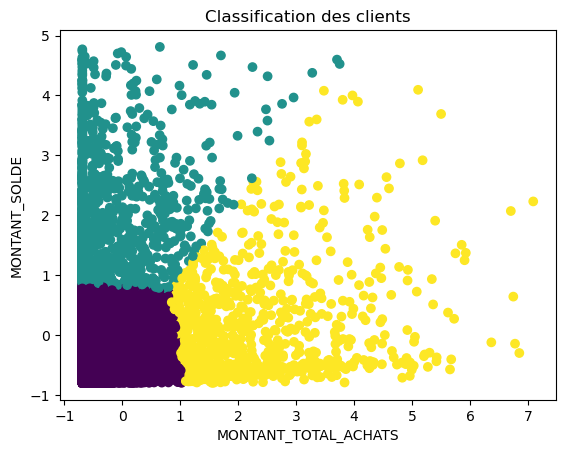

In [40]:
plt.scatter(
    data_norm['MONTANT_TOTAL_ACHATS'],
    data_norm['MONTANT_SOLDE'],
    c=data_norm['cluster'],
    cmap='viridis'
)

plt.xlabel("MONTANT_TOTAL_ACHATS")
plt.ylabel("MONTANT_SOLDE")

plt.title("Classification des clients")

plt.show()

In [41]:
resultat = data_norm.groupby('cluster').agg(
    MONTANT_TOTAL_ACHATS_MOYEN=('MONTANT_TOTAL_ACHATS','mean'),
    MONTANT_SOLDE_MOYEN=('MONTANT_SOLDE','mean'),
    NB_INDIVIDUS=('cluster','count')
)

print(resultat)

         MONTANT_TOTAL_ACHATS_MOYEN  MONTANT_SOLDE_MOYEN  NB_INDIVIDUS
cluster                                                               
0                         -0.307610            -0.366193          6196
1                         -0.201541             2.009243          1100
2                          2.237274             0.061794           951


### Analyse des Clusters
La classification basée sur le montant total des achats et le solde du compte met en évidence trois profils de clients.
Un premier groupe majoritaire (6196 individus) correspond à des utilisateurs peu actifs avec des dépenses et un solde faibles.
Un deuxième groupe de 1 100 individus regroupe des clients présentant un niveau d’endettement très élevé (moyenne de 1.84) malgré des achats relativement modérés.
Enfin, un troisième groupe de 951 individus correspond à des utilisateurs intensifs de la carte de crédit qui réalisent des achats élevés tout en maintenant un solde relativement maîtrisé, proche de zéro.

---

## Régression linéaire en dimension N>2



**Hyphèse r  résulthe d'un phénomène inattendu :**
Nous allons chercher à prédire la Limite de Crédit (`LIMITE_CREDIT`) accordée à un client en fonction de 3 variables : le montant de ses achats (`MONTANT_TOTAL_ACHATS`), le montant de ses remboursements (`MONTANT_PAIEMENT`), et le solde restant sur son compte (`MONTANT_SOLDE`)>.

>* **Phénomène attendu :** Logiquement, plus un client achète et rembourse des montants élevés, plus la banque devrait lui accorder une limite de crédit importi>fs).
>* **Phénomène inattendu recherché :** Quel est l'impact du solde ? Une vision classique voudrait qu'un client très endetté (solde élevé) se voit réduire sa limite de crédit par précaution. Mais dans le modèle économique des cartes de crédit, l'endettement génère des intérêts (agios). Nous supposons donc que le modèle pourrait révéler une corrélation positive contre-intuitive entre le solde et la limite de crédit accordée.

In [46]:

# variables explicatives (X) et de la variable à prédire (y)
variables_X = ['MONTANT_TOTAL_ACHATS', 'MONTANT_PAIEMENT', 'MONTANT_SOLDE']
X = data_norm[variables_X]
y = data_norm['LIMITE_CREDIT']

# 2. Séparation des données (80% pour l'entraînement, 20% pour le test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# 3. Création et entraînement du modèle de régression linéaire multiple
modele_regression = LinearRegression()
modele_regression.fit(X_train, y_train)

print("--- RÉSULTATS DE LA RÉGRESSION LINÉAIRE  ---")
print(f"Ordonnée à l'origine (a0 ou intercept) : {modele_regression.intercept_:.2f}")

print("\nCoefficients des variables explicatives :")
for variable, coefficient in zip(variables_X, modele_regression.coef_):
    print(f"- {variable} : {coefficient:.2f}")

# 5. Évaluation de la précision du modèle
score_r2 = modele_regression.score(X_test, y_test)
print(f"\nScore R² du modèle : {score_r2:.2f}")

--- RÉSULTATS DE LA RÉGRESSION LINÉAIRE  ---
Ordonnée à l'origine (a0 ou intercept) : -0.00

Coefficients des variables explicatives :
- MONTANT_TOTAL_ACHATS : 0.20
- MONTANT_PAIEMENT : 0.15
- MONTANT_SOLDE : 0.40

Score R² du modèle : 0.29


## Analyse des résultats

L'utilisation des données standardisées nous permet de comparer objectivement le poids de chaque variable explicative. L'analyse des coefficients met en évidence une hiérarchie très marquée, dominée par la variable `MONTANT_SOLDE`.

1. Comparaison des résultats obtenus :
En confrontant les coefficients, on observe que le solde (`MONTANT_SOLDE` = 0.40) est le critère le plus déterminant du modèle.

Il pèse près de trois fois plus lourd dans la décision de la banque que le montant remboursé (`MONTANT_PAIEMENT` = 0.15).

Il surpasse largement le total des achats (`MONTANT_TOTAL_ACHAT`= 0.20).

De plus le poids accordé au solde (0.40) est pratiquement équivalent à l'addition de toute l'activité dynamique du client (Achats + Paiements = 0.35).


L'hypothèse classique (Gestion des risques) : Une approche prudente supposerait qu'un client possédant un `MONTANT_SOLDE` très élevé présente un risque de ne pas payer. Logiquement, cela devrait entraîner une diminution de sa `LIMITE_CREDIT` (le coefficient aurait dû être négatif).

La réalité observée : La corrélation est non seulement positive, mais elle surpasse  les autres variables.
On a voulu comprendre pourquoi et comment expliquer ce phénomène et après des recherches voici ce qu'on a découvert :

Un client conservant un solde élevé génère d'importants revenus via les taux d'intérêt. Cette analyse montre que la banque privilégie et augmente la limite de crédit de ces profils à fort potentiel d'endettement, bien plus qu'elle élève la capacité d'un client à rembourser rapidement. trois fois plus fort que le montant remboursé ).


**4. Fiabilité du modèle :**
Notre score $R^2$ de 0.29 indique que ces trois comportements suffisent à eux seuls à expliquer 29% de la variance des limites de crédit accordées. Dans le domaine de l'analyse comportementale, où l'humain est imprévisible, c'est un score significatif qui valide mathématiquement notre hypothèse sur la stratégie de gestion des risques de la banque.

In [48]:
# 1. On demande au modèle de deviner les limites de crédit pour nos 20% de clients "cachés" (X_test)
y_pred = modele_regression.predict(X_test)

# 2. Calcul des erreurs
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Erreur Absolue Moyenne (MAE) : {mae:.2f}") #MAE (Erreur absolue moyenne)
print(f"Erreur Quadratique Moyenne (RMSE) : {rmse:.2f}") #RMSE (Erreur quadratique moyenne)


Erreur Absolue Moyenne (MAE) : 0.63
Erreur Quadratique Moyenne (RMSE) : 0.81


Les performances du modèle ont été évaluées à l’aide de l’erreur absolue moyenne (MAE) et de l’erreur quadratique moyenne (RMSE). Les résultats obtenus montrent que le modèle présente une erreur moyenne modérée, ce qui indique une capacité de prédiction correcte,

In [50]:
# 1. Préparation de la matrice X (DATA) et du vecteur Y
# On ajoute la colonne de 1 manuellement pour l'ordonnée à l'origine (a)
X_mat = np.column_stack((np.ones(len(data_norm)),
                         data_norm['MONTANT_TOTAL_ACHATS'],
                         data_norm['MONTANT_PAIEMENT'],
                         data_norm['MONTANT_SOLDE']))

Y_mat = data_norm['LIMITE_CREDIT'].values

n = X_mat.shape[0] # Nombre de clients
p = X_mat.shape[1] # Nombre de paramètres (4 : a, b, c, d)
ddl = n - p        # Degrés de liberté (n - p)

# 2. Calcul matriciel des coefficients v (ou m) : v = (X^T * X)^-1 * X^T * Y
XtX_inv = np.linalg.inv(X_mat.T @ X_mat)
v = XtX_inv @ X_mat.T @ Y_mat

# 3. Calcul de la Matrice de Variance-Covariance
# On calcule d'abord l'erreur au carré (les résidus)
Y_pred = X_mat @ v
erreurs = Y_mat - Y_pred

# sigma_chapeau^2 = Somme des erreurs au carré / degrés de liberté
sigma2 = np.sum(erreurs**2) / ddl

# La matrice de Variance-Covariance : sigma^2 * (X^T * X)^-1
Matrice_Cov = sigma2 * XtX_inv

# 4. Calcul des Intervalles de Confiance (IC)
# On récupère la diagonale de la matrice et on prend la racine carrée
std_err = np.sqrt(np.diag(Matrice_Cov))

# On va chercher le coefficient de Student (t) pour un intervalle à 95% (environ 1.96)
t_student = stats.t.ppf(0.975, ddl)

print(" CALCUL MATRICIEL DES INTERVALLES DE CONFIANCE\n")
noms_variables = ['Constante (a)', 'Achats (b)', 'Paiements (c)', 'Solde (d)']

for i in range(p):
    coef = v[i]
    erreur_std = std_err[i]
    borne_inf = coef - (t_student * erreur_std)
    borne_sup = coef + (t_student * erreur_std)

    print(f"{noms_variables[i]} :")
    print(f"  -> Coefficient   = {coef:.4f}")
    print(f"  -> Ecart type     = {erreur_std:.4f}")
    print(f"  -> IC à 95%      = [{borne_inf:.4f} ; {borne_sup:.4f}]\n")

 CALCUL MATRICIEL DES INTERVALLES DE CONFIANCE

Constante (a) :
  -> Coefficient   = 0.0000
  -> Ecart type     = 0.0093
  -> IC à 95%      = [-0.0182 ; 0.0182]

Achats (b) :
  -> Coefficient   = 0.2051
  -> Ecart type     = 0.0104
  -> IC à 95%      = [0.1848 ; 0.2255]

Paiements (c) :
  -> Coefficient   = 0.1402
  -> Ecart type     = 0.0108
  -> IC à 95%      = [0.1191 ; 0.1613]

Solde (d) :
  -> Coefficient   = 0.3995
  -> Ecart type     = 0.0097
  -> IC à 95%      = [0.3806 ; 0.4185]



<center><b>Voici la fonction associé</b></center> :$$\text{LIMITE\_CREDIT} = 0.21 \times \text{ACHATS} + 0.14 \times \text{PAIEMENTS} + 0.4 \times \text{SOLDE} + εi$$

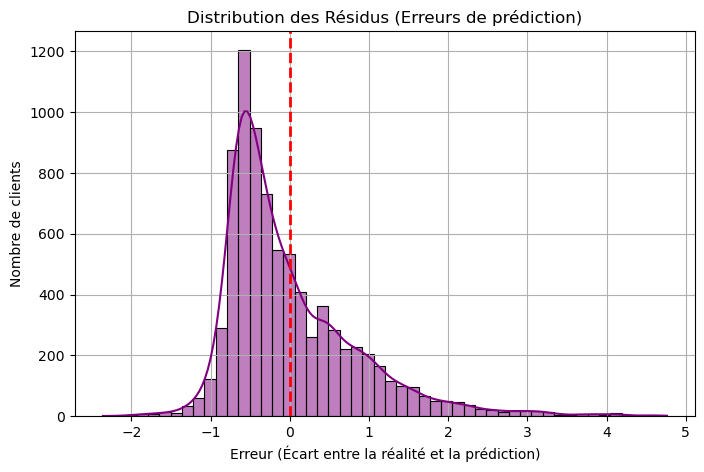

In [52]:
residus = Y_mat - Y_pred

# 2. On trace l'histogramme des erreurs
plt.figure(figsize=(8, 5))
sns.histplot(residus, bins=50, kde=True, color='purple')

# 3. On ajoute une ligne verticale sur le zéro
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)

plt.title('Distribution des Résidus (Erreurs de prédiction)')
plt.xlabel("Erreur (Écart entre la réalité et la prédiction)")
plt.ylabel("Nombre de clients")
plt.grid(True)
plt.show()

###  Analyse des résidus

L'analyse de l'histogramme des résidus (les erreurs de prédiction de notre modèle) nous révèle que la répartition n'est pas parfaitement symétrique $\varepsilon_i \sim \mathcal{N}(0, \sigma)$, mais présente une asymétrie avec une queue à gauche.Cette asymétrie s'explique parfaitement par la répartition démographique de nos clients.

**Le poids écrasant du groupe des "Peu Actifs" :**
Le pic massif que l'on observe du côté des erreurs légèrement négatives (à gauche du zéro) correspond au groupe de clients le plus conséquent de notre base de données : **les clients peu actifs à faible activité**.

Comme nous l'avons identifié (et allons le voir) grâce à notre algorithme de Clustering, ce groupe majoritaire a un comportement neutre (peu d'achats, solde faible). Or,notre regression essaie de tracer une droite unique pour tout le monde en prenant en compte les valeurs plus élevés. En essayant de lisser les prédictions pour s'adapter à la fois à cette masse inactive et aux quelques profils très riches,  il a tendance à attribuer une limite de crédit légèrement surestimée à ces clients inactifs.



----

##  Classification en dimension N > 2

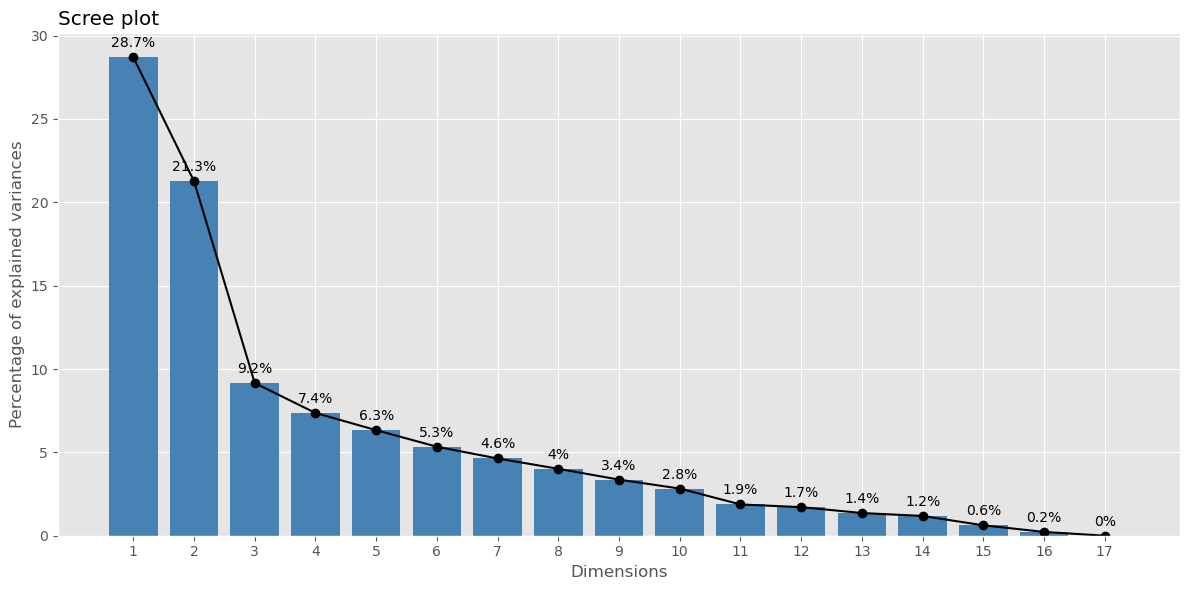

In [56]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

y = PCA().fit(data_norm.drop(columns=["cluster"], errors="ignore")).explained_variance_ratio_ * 100
x = range(1, len(y) + 1)

plt.style.use("ggplot")
plt.figure(figsize=(12, 6))
plt.bar(x, y, color="steelblue")
plt.plot(x, y, "ko-")
for i, v in enumerate(y, 1): plt.text(i, v + 0.6, f"{v:.1f}%".replace(".0%", "%"), ha="center")
plt.title("Scree plot", loc="left")
plt.xlabel("Dimensions")
plt.ylabel("Percentage of explained variances")
plt.xticks(x)
plt.tight_layout()
plt.show()

### **Scree plot**
Le scree plot montre la part de variance expliquée par chaque composante principale. On observe que la première composante (Dim1) explique environ 28.7% de la variance, suivie de la deuxième (Dim2) avec 21.3%. À elles deux, ces deux dimensions expliquent donc près de 50% de l’information totale, ce qui est significatif.

On remarque une forte chute de la variance expliquée entre la deuxième et la troisième composante (passage de 21.3% à 9.2%). Ce phénomène correspond à un “coude” (elbow) sur le graphique, indiquant que les deux premières dimensions capturent l’essentiel de la structure des données.

[0.49006034 0.25023754]


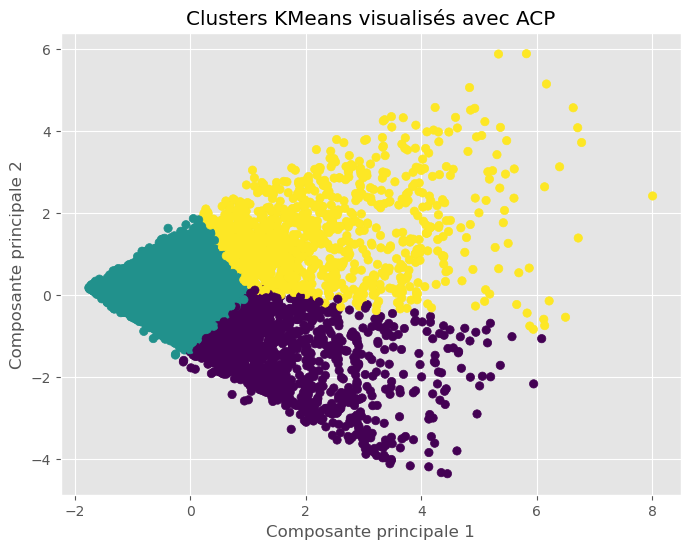

In [58]:
# 4 variables (dimension 4)
variables_4d = [
    'MONTANT_TOTAL_ACHATS',
    'MONTANT_PAIEMENT',
    'MONTANT_SOLDE',
    'LIMITE_CREDIT'
]

X = data_norm[variables_4d]

# KMeans
kmeans = KMeans(n_clusters=3, random_state=0)
clusters = kmeans.fit_predict(X)

# ACP (PCA) pour visualiser
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print(pca.explained_variance_ratio_) # ≈ 72.7% de l’information conservée

# Visualisation
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.title("Clusters KMeans visualisés avec ACP")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.grid(True)
plt.show()

Le graphique montre que les trois clusters sont bien séparés dans le plan ACP, ce qui confirme l’existence de profils clients distincts. On observe notamment un groupe peu actif (compact et proche de l’origine), un groupe de clients actifs et un groupe plus dispersé correspondant à des clients fortement utilisateurs du crédit. Cette séparation visuelle valide la pertinence du clustering et met en évidence des comportements financiers clairement différenciés.

In [60]:
X = data_norm[[
    'MONTANT_TOTAL_ACHATS',
    'MONTANT_PAIEMENT',
    'MONTANT_SOLDE'
]]

y = data_norm['LIMITE_CREDIT']

for c in np.unique(clusters):
    mask = clusters == c
    model = LinearRegression().fit(X[mask], y[mask])
    print(f"Cluster {c} R2:", model.score(X[mask], y[mask]))

Cluster 0 R2: 0.032497230509163644
Cluster 1 R2: 0.02322406834960511
Cluster 2 R2: 0.028051511548778385


### Analyse des Clusters a l'aide de la regression
L’analyse par clusters révèle que les variables explicatives utilisées n’ont qu’un faible pouvoir prédictif au sein de chaque groupe homogène (R² ≈ 0.02 à 0.03). Cela indique que la relation observée dans le modèle global (R² = 0.29) est principalement due à des différences structurelles entre les profils clients, plutôt qu’à une relation linéaire intrinsèque entre les variables. La limite de crédit semble ainsi davantage dépendre du profil global du client que de ses comportements financiers individuels.

---

## Analyse en composante principale

### Introduction à l'Analyse en Composantes Principales (ACP)

Maintenant que nous avons étudié la limite de crédit à l'aide de la régression linéaire et la classification, nous nous retrouvons face à un défi   pour continuer notre exploration : notre dataset contient 17 variables financières par client.Il est impossible de visualiser un graphique en 17 dimensions pour y repérer des grandes tendances ou des groupes de clients atypiques.

De plus, beaucoup de ces indicateurs sont liés et disent la même chose. Par exemple, un client qui possède un fort montant total d'achats aura logiquement un nombre de transactions élevé et des paiements réguliers. Garder toutes ces variables séparées crée de la redondance et brouille les pistes.

C'est précisément pour regler ce problème que nous utilisons l'Analyse en Composantes Principales (ACP). Son objectif est de synthétiser l'information en fusionnant les variables fortement corrélées. En"écrasant nos 17 dimensions pour n'en garder que deux ou trois grands axes, l'ACP va nous permettre de cartographier nos 5947 clients sur un simple plan en dimension 2.

Elle va nous donner une première vision visuelle de la répartition de nos clients et ainsi faire une classification des clients par la suite.

> **Note sur le choix des dimensions :**
> Lors de l'analyse des valeurs propres, l'application de la « méthode du coude » nous a conduits à ne retenir que les **deux premiers axes principaux**. À eux seuls, ces deux axes parviennent à capturer environ **50 % de la variance totale**. Autrement dit, nous réussissons à résumer la moitié de l'information complexe contenue dans l'ensemble de nos variables initiales sur seulement deux dimensions..

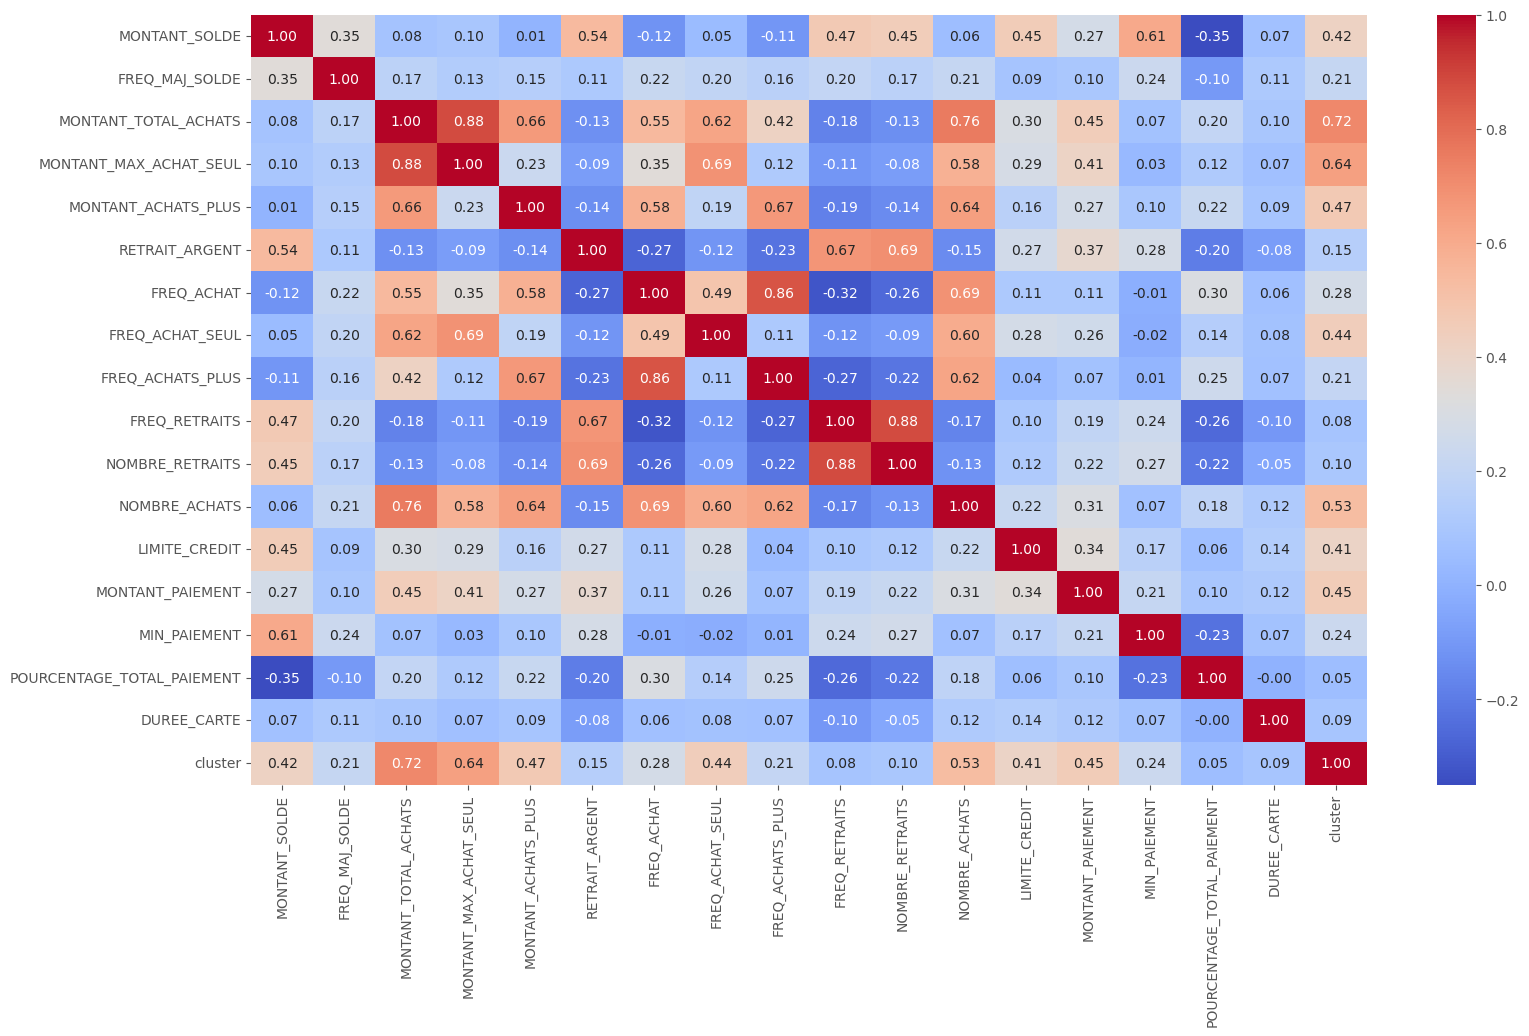

In [66]:
plt.figure(figsize = (18,10))
sns.heatmap(data_norm.corr(), cmap= 'coolwarm',annot = True , fmt='.2f' )
plt.show()

# Analyse matrice

La matrice de corrélation standardisé met en évidence plusieurs relations importantes entre les variables.
Les variables liées aux achats présentent de fortes corrélations entre elles, notamment entre le montant total des achats et le montant maximum d’un achat unique (0.88).
De même, les variables associées aux retraits d’argent sont fortement corrélées, en particulier entre la fréquence des retraits et le nombre de retraits (0.80).


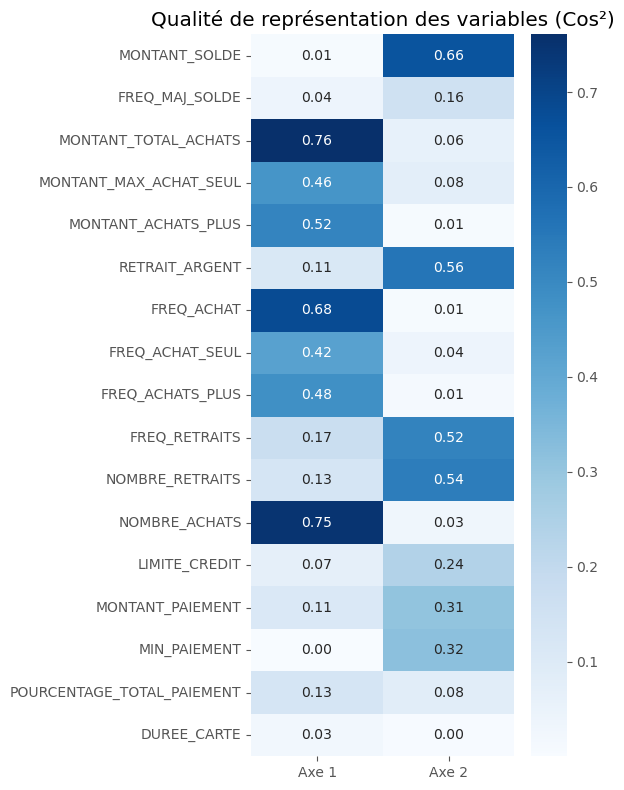

In [68]:
# 1) Préparer les données
data_pca = data_norm.drop(columns=["cluster"], errors="ignore")

# 2) Faire l'ACP sur 2 axes
pca = PCA(n_components=2).fit(data_pca)

# 3) Calcul des cos²
var_coord = pca.components_.T * np.sqrt(pca.explained_variance_)
cos2 = var_coord**2

# 4) DataFrame
cos2_df = pd.DataFrame(
    cos2,
    index=data_pca.columns,
    columns=["Axe 1", "Axe 2"]
)
# 5) Heatmap
plt.figure(figsize=(6, 8))
sns.heatmap(cos2_df, annot=True, cmap="Blues", fmt=".2f", cbar=True)

plt.title("Qualité de représentation des variables (Cos²)")
plt.tight_layout()
plt.show()

### Interprétation de la qualité de représentation (Cos²)

Ce tableau des Cos² permet de décrypter nos nouveaux axes créés par l'ACP. En statistiques, le Cos² mesure la qualité de projection d'une variable sur un axe (allant de 0 à 1). Plus la valeur est élevée et la case foncée, plus la variable est liée à cet axe.

En observant les nuances de bleu sur notre tableau, la signification métier de nos deux nouvelles composantes principales se dessine très nettement :

**L'Axe 1 : L'intensité de consommation**
On remarque immédiatement que la première colonne capte toute l'activité d'achat de nos clients. Les variables qui y sont le mieux représentées sont le `NOMBRE_ACHATS` (0.75), le `MONTANT_TOTAL_ACHATS` (0.76) et la `FREQ_ACHAT` (0.68). Les transactions en plusieurs fois ou ponctuelles y ont également un poids significatif (autour de 0.50). Ce premier axe mesure l'utilisation quotidienne de la carte bancaire pour consommer.

**L'Axe 2 : L'endettement et les fluctations d'argent**
La deuxième colonne capture des comportements totalement différents. La variable qui domine cet axe est le `MONTANT_SOLDE` (0.66), suivie de très près par toutes les opérations liées aux avances de fonds et retraits d'espèces (`RETRAIT_ARGENT` à 0.56, `NOMBRE_RETRAITS` à 0.54). Les variables de remboursement (`MONTANT_PAIEMENT`, `MIN_PAIEMENT`) sont également bien captées par cet axe. Cette composante représente donc le besoin de liquidité, la gestion de la dette et la dynamique de remboursement du client.

**Les variables effacées :**
Il est également intéressant de noter que la `DUREE_CARTE`ou bien `POURCENTAGE_TOTAL_PAIEMENT` (l'ancienneté) affiche des scores quasiment nuls (0.03 et 0.00). Elle n'a aucune influence sur nos deux axes principaux.


Le prochain graphique, le **cercle des corrélations**, va nous permettre de confirmer visuellement cette dynamique géométrique : nous devrions y voir les flèches liées aux achats s'étirer massivement le long de l'axe horizontal (Axe 1), tandis que les variables liées au solde et aux retraits pointeront le long de l'axe vertical (Axe 2).


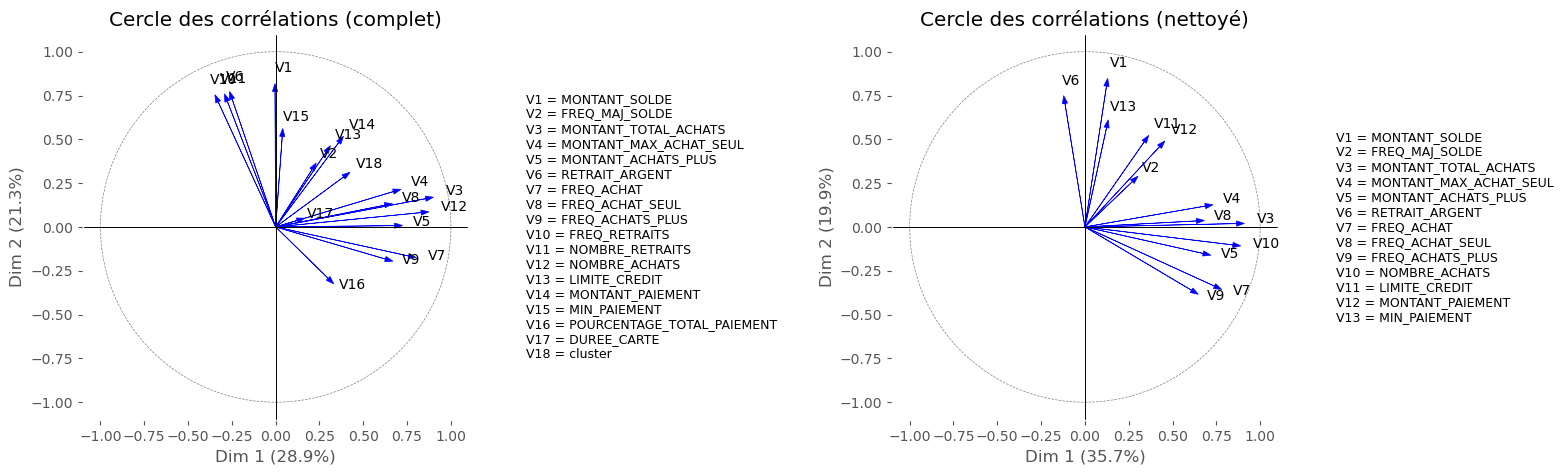

In [70]:
X1 = data_norm
X2 = data_norm.drop(columns=['NOMBRE_RETRAITS','FREQ_RETRAITS','POURCENTAGE_TOTAL_PAIEMENT','DUREE_CARTE','cluster'], errors="ignore")

fig, ax = plt.subplots(1, 2, figsize=(16, 8), facecolor="white")
for a in ax: a.set_facecolor("white")
cercle(ax[0], X1, "Cercle des corrélations (complet)")
cercle(ax[1], X2, "Cercle des corrélations (nettoyé)")
plt.tight_layout()
plt.show()

### 1. Analyse du cercle des corrélations initial (Jeu de données complet)

### Analyse du cercle des corrélations (avant nettoyage)

Le premier cercle des corrélations représente la projection de l'intégralité de nos **18 variables** initiales (incluant la variable `cluster` insérée par erreur) sur les deux premiers axes de l'ACP. Bien qu'il nous donne une première tendance, ce graphique illustre parfaitement le problème de la "malédiction de la dimensionnalité" et de la redondance des données :

* **Une très forte colinéarité (redondance) :** Les vecteurs forment des grappes extrêmement denses. On constate que les flèches se superposent presque parfaitement, notamment sur les variables de retraits d'argent en haut à gauche (`RETRAIT_ARGENT`, `FREQ_RETRAITS`, `NOMBRE_RETRAITS` - V6, V10, V11). C'est également le cas pour les variables d'achats à l'horizontale (V3, V4, V5, V8, V12). Garder toutes ces variables séparées revient à faire peser plusieurs fois la même information dans notre modèle.
* **Des variables mal représentées (bruit) :** Certaines flèches sont très courtes et restent bloquées près du centre du cercle. C'est le cas de la `DUREE_CARTE` (V17) ou encore du `POURCENTAGE_TOTAL_PAIEMENT` (V16). Cela signifie qu'elles sont très mal représentées par ce plan 2D et n'apportent aucune information utile pour différencier nos clients sur ces axes.
* **Premières tendances :** Malgré ce bruit visuel, on devine déjà la spécialisation de nos deux axes : l'axe horizontal (Dim 1) est clairement tiré vers la droite par la consommation et les achats, tandis l'axe vertical (Dim 2) est tiré vers le haut par l'endettement (`MONTANT_SOLDE` - V1) et les retraits d'espèces.

**Conclusion :** Pour obtenir une ACP robuste et lisible, il est impératif de nettoyer la base de données. Nous devons supprimer les variables non pertinentes (ou fausses, comme le `cluster`), retirer celles qui sont mal représentées, et regrouper les variables parfaitement colinéaires pour ne pas biaiser l'algorithme.

---

### 2. Analyse du cercle des corrélations optimisé (Après nettoyage)

Suite au regroupement des variables similaires (notamment les retraits) et à la suppression des données non contributives, notre nouveau cercle des corrélations est beaucoup plus clair et mathématiquement plus fort.

* **Une meilleure concentration de l'information :** Preuve que notre nettoyage est réussi, le premier axe (Dim 1) concentre désormais à lui seul **35.7 %** de l'information totale (contre 29 % auparavant). Les vecteurs sont également plus longs (proches du cercle de rayon 1), ce qui confirme que la qualité de représentation ($Cos^2$) globale a augmenté.
* **La confirmation de l'Axe 1 (Comportement d'Achat) :** L'axe horizontal est désormais très nettement défini par les variables liées à la consommation active. On y retrouve le `MONTANT_TOTAL_ACHATS` (V3), le `NOMBRE_ACHATS` (V9), et la `FREQ_ACHAT` (V6). Plus un client se trouvera à droite du graphique, plus il utilisera sa carte pour consommer.
* **La confirmation de l'Axe 2 (Endettement et Remboursement) :** L'axe vertical est dominé par le `MONTANT_SOLDE` (V1) qui pointe tout en haut, suivi des variables de paiements (`MIN_PAIEMENT`, `MONTANT_PAIEMENT`). Cet axe illustre la gestion de la dette et le besoin de trésorerie du client.

**Bilan :**  L'Axe 1 est l'axe des dépenses commerciales, l'Axe 2 est l'axe de la dette bancaire. Nous pouvons désormais projeter nos clients sur ce repère.

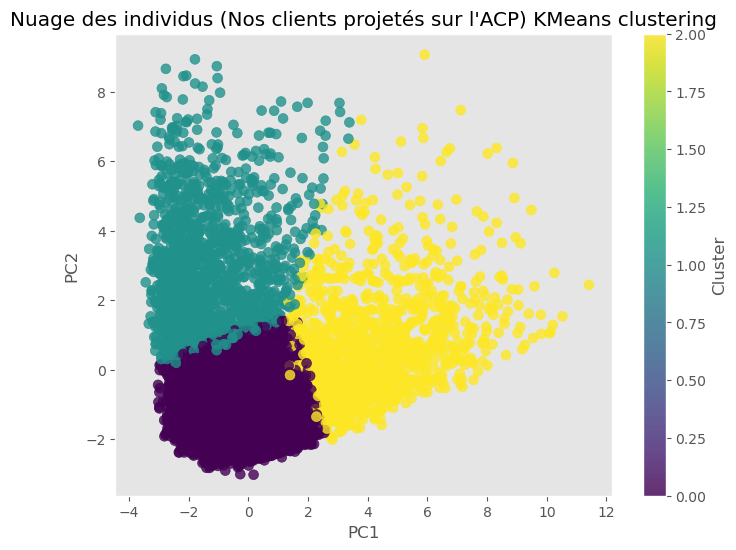

In [72]:
# ACP
pca = PCA(n_components=2)
X_pca = pca.fit_transform(data_norm)

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(data_norm)

# Plot
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    cmap='viridis',
    s=50,
    alpha=0.8
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title("Nuage des individus (Nos clients projetés sur l'ACP) KMeans clustering")
plt.grid()

plt.colorbar(label='Cluster')
plt.show()

### 3. Analyse des clusters : La révélation des profils clients

L'application de l'algorithme K-Means sur nos données projetées par l'ACP a permis de segmenter notre clientèle en trois grands groupes distincts. En nous basant sur la signification de nos axes (PC1 pour les achats à l'horizontale, PC2 pour l'endettement à la verticale), nous pouvons enfin dresser le profil de ces clients :

**Le Cluster Violet (En bas à gauche) : La masse des "Peu Actifs"**
Ce groupe est caractérisé par des scores faibles sur les deux axes (peu d'achats, solde faible). Visuellement, c'est le bloc le plus dense et le plus massif de notre graphique. Il représente le client standard ou "dormant", qui utilise sa carte de manière occasionnelle sans accumuler de dettes.

**Le Cluster Vert (En haut à gauche) : Les "Endettés Rentables"**
Ces clients ont un score faible sur l'axe des achats (PC1), mais explosent les compteurs sur l'axe vertical (PC2). Ce sont des utilisateurs qui consomment peu au quotidien avec leur carte, mais qui maintiennent un solde très élevé et effectuent des retraits ou des avances de fonds. Pour la banque, ce profil génère énormément de revenus grâce aux intérêts (expliqués a l'étape de la régression N>2)

**Le Cluster Jaune (À droite) : Les "Acheteurs Actifs**
Ce groupe s'étire massivement vers la droite (PC1 fort). Ce sont les clients qui utilisent intensivement leur carte pour régler leurs achats (forte fréquence et gros montants). Leur niveau d'endettement (PC2) est variable, mais leur caractéristique principale reste leur fièvre acheteuse. Ils génèrent de la rentabilité via les frais de transaction facturés aux commerçants.


---


### Conclusion générale : Réponse à notre problématique

Notre problématique initiale visait à comprendre **comment la banque peut adapter ses stratégies, notamment la gestion des risques, en fonction des profils de consommation et d'endettement de ses clients**.

Dans notre première partie), la régression linéaire nous avait prouvé mathématiquement que le niveau d'endettement (`MONTANT_SOLDE`) jouait un role majeur dans les décisions de la banque. Cependant, ce modèle global montrait des limites : appliquer une seule méthode de décision à toute une base de clients est  imprécis et stratégiquement inefficace.

Le graphique de clustering nous l'explique très bien : **la gestion des risques ne peut pas être globale, car elle fait face à trois profils aux comportements de consommation et d'endettement totalement différents.**

* Le poids massif du **groupe Violet ("Les Peu Actifs")** créait le biais observé dans nos résidus. Pour eux, l'endettement et le risque financier sont quasi nuls. La stratégie de la banque ne doit donc pas être défensive (gestion du risque), mais proactive : il faut des campagnes marketing ciblées pour stimuler leur consommation.
* L'importance du solde révélée par notre régression linéaire était en réalité dictée par le **groupe Vert ("Les Endettés")**. C'est ici que se trouve le véritable défi de la gestion des risques. Ces clients rapportent beaucoup d'intérêts grâce à leur dette, mais la banque prend de gros risques. La stratégie doit être une surveillance stricte des plafonds pour éviter le surendettement et le défaut de paiement.
* Le modèle global échouait sur le **groupe Jaune ("Les Acheteurs Actifs")**, car pour ces clients, la banque n'utilise pas la dette pour évaluer le profil, mais récompense le volume d'achats. Le risque étant maîtrisé (ils remboursent ce qu'ils consomment), la stratégie bancaire doit basculer sur la fidélisation pure (augmenter proactivement les limites, offrir des cartes Premium) pour éviter qu'ils ne partent à la concurrence.

**Bilan :** Nous avons prouvé qu'une banque moderne ne peut pas se contenter d'un modèle mathématique unique pour gérer ses risques. L'attribution du crédit et la stratégie commerciale doivent être faites sur-mesure, en s'adaptant directement au profil du client (logique de stimulation, de surveillance de la dette, ou de fidélisation par la consommation).

In [74]:
data_norm.head()

,MONTANT_SOLDE,FREQ_MAJ_SOLDE,MONTANT_TOTAL_ACHATS,MONTANT_MAX_ACHAT_SEUL,MONTANT_ACHATS_PLUS,RETRAIT_ARGENT,FREQ_ACHAT,FREQ_ACHAT_SEUL,FREQ_ACHATS_PLUS,FREQ_RETRAITS,NOMBRE_RETRAITS,NOMBRE_ACHATS,LIMITE_CREDIT,MONTANT_PAIEMENT,MIN_PAIEMENT,POURCENTAGE_TOTAL_PAIEMENT,DUREE_CARTE,cluster
0,-0.770686,-0.237350,-0.608283,-0.516720,-0.435764,-0.541588,-0.798408,-0.669420,-0.698450,-0.681002,-0.568946,-0.620843,-0.991755,-0.724827,-0.526297,-0.522401,0.339013,0
1,1.046726,0.141807,-0.690479,-0.516720,-0.606202,3.893112,-1.216392,-0.669420,-0.909717,0.705072,0.276515,-0.737183,0.858715,1.652242,0.486995,0.246490,0.339013,1
2,0.640127,0.520964,-0.024319,0.347426,-0.606202,-0.541588,1.291506,2.766907,-0.909717,-0.681002,-0.568946,-0.039147,1.012921,-0.468754,0.003551,-0.522401,0.339013,0
3,0.163880,-0.995665,0.601054,1.158662,-0.606202,-0.399944,-1.007402,-0.383061,-0.909717,-0.218979,-0.357581,-0.679013,1.012921,-0.847788,-0.677840,-0.522401,0.339013,0
4,-0.324138,0.520964,-0.676694,-0.498837,-0.606202,-0.541588,-1.007402,-0.383061,-0.909717,-0.681002,-0.568946,-0.679013,-0.930073,-0.434470,-0.411934,-0.522401,0.339013,0
